In [ ]:
import pandas as pd
import numpy as np
df = pd.read_pickle('/data/users2/jwardell1/undersampling-project/results-2025-02-08-1739000965.pkl')
snrs = np.unique(df['snr'])
srs = np.unique(df['sr'])

for snr in snrs:
    for sr in srs:
        curr_df = df[(df['sr'] == sr) & (df['snr'] == snr)]
        num_lines = len(curr_df)
        for i in range(num_lines):
            curr_row = curr_df.iloc[i]
            p_values = curr_row['p_values']
            fdr_p_values = curr_row['fdr_corrected_pvals']
            num_sig_p = len(np.where(p_values < 0.05)[0])
            num_sig_fdr = len(np.where(fdr_p_values < 0.05)[0])
            if(num_sig_fdr > 0):
                print(f'sr {sr}   snr {snr}   significant pvalues - {num_sig_p}')
                print(f'sr {sr}   snr {snr}   significant fdr_pvalues - {num_sig_fdr}')
                print('\n\n')


sr sr1   snr 1.5   significant pvalues - 316
sr sr1   snr 1.5   significant fdr_pvalues - 118



sr sr2   snr 1.5   significant pvalues - 945
sr sr2   snr 1.5   significant fdr_pvalues - 906



sr sr1   snr 1.6   significant pvalues - 415
sr sr1   snr 1.6   significant fdr_pvalues - 209



sr sr1   snr 1.7   significant pvalues - 976
sr sr1   snr 1.7   significant fdr_pvalues - 942



sr sr2   snr 1.7   significant pvalues - 873
sr sr2   snr 1.7   significant fdr_pvalues - 830



sr sr1   snr 1.8   significant pvalues - 922
sr sr1   snr 1.8   significant fdr_pvalues - 872



sr add   snr 1.9   significant pvalues - 423
sr add   snr 1.9   significant fdr_pvalues - 214



sr concat   snr 1.9   significant pvalues - 530
sr concat   snr 1.9   significant fdr_pvalues - 116



sr sr1   snr 1.9   significant pvalues - 835
sr sr1   snr 1.9   significant fdr_pvalues - 777



sr sr1   snr 2.0   significant pvalues - 714
sr sr1   snr 2.0   significant fdr_pvalues - 620



sr sr2   snr 2.0   signi

/data/users2/jwardell1/undersampling-project/OULU/pkl-files/FBIRN/02-06/rwp

📌 SNR where ADD has the largest difference: 2.2

📌 Bonferroni Corrected p-values for ADD vs. other Sampling Rates:
sr1: 0.00094
sr2: 0.00005
concat: 0.00150


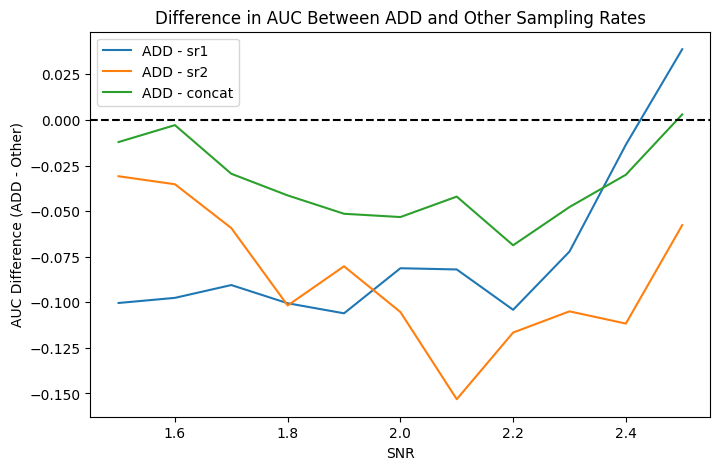

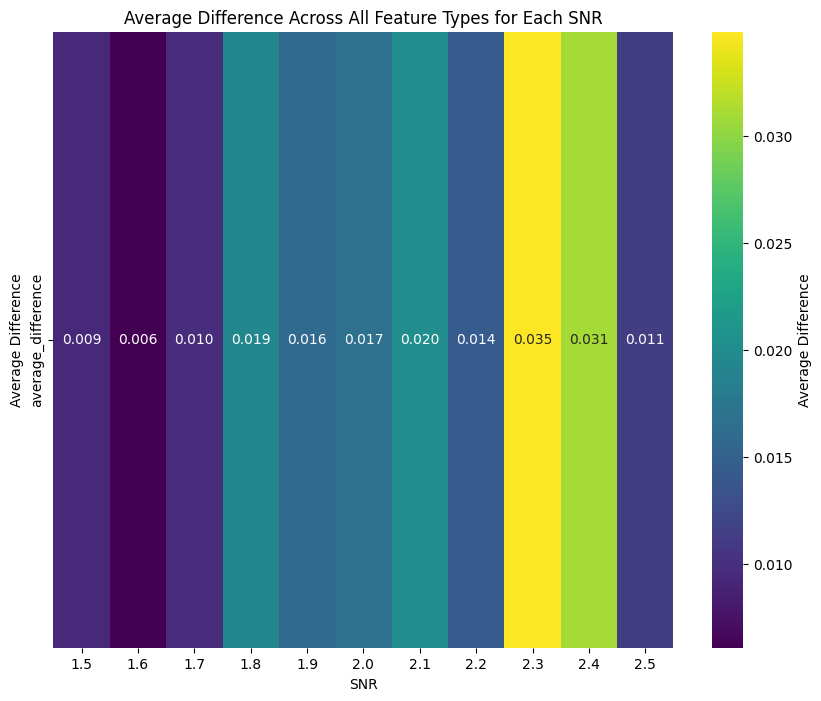

The SNR with the largest overall difference from 'add' is 2.3 with a difference of 0.035


In [13]:
from scipy.stats import ttest_rel, wilcoxon

all_data = load_results()
if all_data['test_scores'].apply(lambda x: isinstance(x, (list, np.ndarray))).any():
    all_data = all_data.explode('test_scores')

all_data = all_data.explode('test_scores')
mean_auc = all_data.groupby(['snr', 'sampling_rate'])['test_scores'].mean().unstack()
differences = mean_auc.subtract(mean_auc['add'], axis=0)

# Find the SNR where ADD has the largest difference (absolute value)
largest_diff_snr = differences.abs().sum(axis=1).idxmax()
print(f"\n📌 SNR where ADD has the largest difference: {largest_diff_snr}")

# Perform paired t-tests for statistical significance
p_values = {}
for sr in ['sr1', 'sr2', 'concat']:
    if sr in mean_auc.columns:
        try:
            t_stat, p = ttest_rel(mean_auc['add'].dropna(), mean_auc[sr].dropna())  # Ensure no NaNs
            p_values[sr] = p
        except ValueError:
            print(f"Skipping T-test for {sr} due to insufficient data.")

# Apply Bonferroni correction (adjust for multiple comparisons)
num_tests = len(p_values)
p_values_corrected = {sr: min(p * num_tests, 1) for sr, p in p_values.items()}

# Print corrected p-values
print("\n📌 Bonferroni Corrected p-values for ADD vs. other Sampling Rates:")
for sr, p_val in p_values_corrected.items():
    print(f"{sr}: {p_val:.5f}")

# Plot differences across SNRs
plt.figure(figsize=(8, 5))
for sr in ['sr1', 'sr2', 'concat']:
    if sr in differences.columns:
        plt.plot(differences.index, differences[sr], label=f'ADD - {sr}')

plt.axhline(0, linestyle="--", color="black")
plt.xlabel("SNR")
plt.ylabel("AUC Difference (ADD - Other)")
plt.legend()
plt.title("Difference in AUC Between ADD and Other Sampling Rates")
plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming the data is already in a DataFrame called differences
data = {
    'snr': [1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5],
    'add': [0.0]*11,
    'concat': [0.002026, 0.010497, 0.005385, 0.001367, 0.015028, 0.010703, 0.024308, 0.023493, 0.022701, 0.020307, 0.021783],
    'sr1': [0.029894, 0.011473, 0.00192, 0.02428, 0.010653, 0.023454, 0.008644, 0.014665, 0.024576, 0.016155, 0.00252],
    'sr2': [0.005776, 0.002439, 0.031741, 0.052305, 0.037974, 0.032762, 0.047924, 0.019436, 0.092288, 0.087472, 0.020633]
}

differences = pd.DataFrame(data)
differences.set_index('snr', inplace=True)

# Calculate the average difference across all feature types for each SNR
average_differences = differences.mean(axis=1).to_frame(name='average_difference')

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(average_differences.T, annot=True, cmap='viridis', fmt=".3f", cbar_kws={'label': 'Average Difference'})
plt.title('Average Difference Across All Feature Types for Each SNR')
plt.xlabel('SNR')
plt.ylabel('Average Difference')
plt.show()

# Determine the SNR with the largest overall difference from add
largest_difference_snr = average_differences.idxmax().values[0]
largest_difference_value = average_differences.max().values[0]

print(f"The SNR with the largest overall difference from 'add' is {largest_difference_snr} with a difference of {largest_difference_value:.3f}")

In [2]:
import pandas as pd

res_df = pd.read_pickle('results-2025-02-13-1739462740.pkl')
res_df

,sr,snr,p_values,fdr_corrected_pvals,reject,w,reg
0,sr1,2.3,"[0.8211788211788211, 0.4925074925074925, 0.375...","[0.900870186475087, 0.651366193880057, 0.53431...","[False, False, False, False, False, True, Fals...","[-2.390089728890564e-17, -0.04353052952523382,...",0.100
1,sr2,2.3,"[0.16983016983016982, 0.35064935064935066, 0.0...","[0.30801897722049815, 0.5078737052421263, 0.10...","[False, False, False, False, False, True, Fals...","[1.682700473189006e-18, -0.003014237061503348,...",0.001
2,add,2.3,"[0.9600399600399601, 0.7742257742257742, 0.142...","[0.9785022669638055, 0.8737516426790874, 0.277...","[False, False, False, False, False, True, Fals...","[7.943138713890363e-18, -0.020940070435546656,...",0.100
3,concat,2.3,"[0.9270729270729271, 0.4035964035964036, 0.877...","[0.9754715872362932, 0.6950017491533736, 0.963...","[False, False, False, False, False, False, Fal...","[8.213638575674599e-18, -0.04891781495202117, ...",0.100


In [4]:
import numpy as np
p = np.load('/data/users2/jwardell1/feature-importance/connectograms/02-10/sr1_snr_1.7_fdr_pvals.npy')
p.shape

(1431,)

In [9]:
np.save('/data/users2/jwardell1/feature-importance/connectograms/02-14/sr1_snr_2.3_coeff.npy', res_df.iloc[0]['w'])
np.save('/data/users2/jwardell1/feature-importance/connectograms/02-14/sr2_snr_2.3_coeff.npy', res_df.iloc[1]['w'])
np.save('/data/users2/jwardell1/feature-importance/connectograms/02-14/add_snr_2.3_coeff.npy', res_df.iloc[2]['w'])
np.save('/data/users2/jwardell1/feature-importance/connectograms/02-14/concat_snr_2.3_coeff.npy', res_df.iloc[3]['w'])

In [24]:
sr = 'add'
#pvals = res_df[res_df['sr'] == 'add']['fdr_corrected_pvals'].iloc[0]
pvals = res_df.iloc[2]['fdr_corrected_pvals']
np.where(pvals < 0.05)

(array([   5,   14,   18,   19,   21,   25,   26,   30,   33,   35,   38,
          39,   41,   42,   52,   60,   63,   67,   76,   77,   78,   83,
          85,   97,   99,  103,  104,  107,  109,  113,  114,  115,  116,
         120,  125,  127,  129,  141,  144,  147,  149,  150,  151,  158,
         160,  162,  165,  166,  173,  174,  177,  179,  184,  188,  189,
         190,  191,  192,  193,  197,  200,  201,  202,  203,  204,  205,
         208,  212,  213,  214,  217,  224,  241,  242,  248,  256,  261,
         262,  264,  266,  267,  272,  275,  279,  283,  285,  291,  292,
         297,  299,  301,  304,  309,  310,  312,  314,  319,  324,  327,
         335,  337,  343,  345,  346,  349,  351,  358,  364,  367,  370,
         374,  379,  388,  391,  397,  398,  399,  401,  412,  417,  423,
         427,  435,  439,  440,  442,  443,  459,  475,  477,  490,  495,
         498,  499,  506,  507,  512,  514,  516,  537,  542,  543,  548,
         558,  562,  563,  564,  569, 